# Conservation Testing
This notebook is created to test the number of time points that are needed to integrate over to reduce the error of the KdV PINN plotting the time to train against the error of the model

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import gc
import pickle

import sys
from pathlib import Path

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

from models import KDV

In [3]:
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")
testing_seeds = [42, 72, 83, 27, 81, 174, 9705, 2006, 172, 1969, 1975, 92625, 10000, 2342345, 986689]

CUDA available: True


# One Soliton Testing

In [ ]:
testing_indices_1 = [0, 1, 2, 5, 10, 25, 50]

experiment_results_1_soliton_e_low = []

print("Starting 1-Soliton Experiment Energy (low weight) Experiment...")

for testing_val in testing_indices_1:
    results = {
        'time': [],
        'mae': [],
        'max_error': []
    }
   
    for current_seed in testing_seeds:

        INIT_PARAMS = dict(
            num_solitons             = 1,
            n_hidden_layers          = 4, 
            n_neurons_per_layer      = 32, 
            activation               = nn.Tanh,
            seed                     = current_seed, 
            verbose                  = False,
        )
        
        TRAIN_PARAMS = dict(
            adam_epochs              = 1000,
            verbose_step             = 100,
            n_collocation            = 50000, 
            n_initial                = 30000,  
            n_boundary               = 10000,
            n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
            n_energy                 = testing_val,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
            adam_lr                  = 1e-3,   
            lbfgs_lr                 = 1.0,    
            lbfgs_history_size       = 100, 
            lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
            adaptive_sampling        = False,   
            logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
            verbose                  = False,
        )

        TRAIN_WEIGHTS = dict( #seperated out from the train params
            w_ic                     = 5.0,    
            w_bc                     = 2.0,    
            w_pde                    = 15.0,
            w_momentum               = 1.0,
            w_energy                 = 0.1,
        )
    
        model = KDV(INIT_PARAMS)
        training_stats, _ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)
        error_stats = model.test(nx = 1000, nt=1000, error_type='absolute-normalized')

        print(f"  -> Integrals: {testing_val:<4} | Seed: {current_seed:<4} | Time: {training_stats.time:6.2f} s | MAE: {error_stats.mae:.6e}")

        results['time'].append(training_stats.time)
        results['mae'].append(error_stats.mae)
        results['max_error'].append(error_stats.max_error)
        
        # Explicitly free up GPU memory
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    experiment_results_1_soliton_e_low.append({
        'n_integrals': testing_val,
        'time_mean': float(np.mean(results['time'])),
        'time_std': float(np.std(results['time'])),
        'mae_mean': float(np.mean(results['mae'])),
        'mae_std': float(np.std(results['mae'])),
        'raw_data': results
    })
    
    # Save a backup to disk
    with open('1_soliton_e_low_backup.pkl', 'wb') as f:
        pickle.dump(experiment_results_1_soliton_e_low, f)
    
    print(f"=== Finished n_energy={testing_val} | Avg MAE: {experiment_results_1_soliton_e_low[-1]['mae_mean']:.6e} ===\n")
        
print("1 Soliton Experiment LOW ENERGY OVER!")

Starting 1-Soliton Experiment Energy (low weight) Experiment...


/home/jairdan/miniconda3/envs/soliton-pinns/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/home/jairdan/soliton-pinns/models/kdv_2/loss.py:200: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses['total'].append(float(total_loss))


  -> Integrals: 0    | Seed: 42   | Time:  25.86 s | MAE: 3.953666e-03
  -> Integrals: 0    | Seed: 72   | Time:  22.70 s | MAE: 3.859125e-03
  -> Integrals: 0    | Seed: 83   | Time:  24.78 s | MAE: 5.141680e-03
  -> Integrals: 0    | Seed: 27   | Time:  44.38 s | MAE: 1.195796e-03
  -> Integrals: 0    | Seed: 81   | Time:  26.75 s | MAE: 1.666212e-03
  -> Integrals: 0    | Seed: 174  | Time:  25.78 s | MAE: 2.331426e-03
  -> Integrals: 0    | Seed: 9705 | Time:  25.11 s | MAE: 3.251429e-03
  -> Integrals: 0    | Seed: 2006 | Time:  20.26 s | MAE: 2.668197e-03
  -> Integrals: 0    | Seed: 172  | Time:  23.77 s | MAE: 2.111738e-03
  -> Integrals: 0    | Seed: 1969 | Time:  23.17 s | MAE: 1.683855e-03
  -> Integrals: 0    | Seed: 1975 | Time:  34.75 s | MAE: 4.548267e-03
  -> Integrals: 0    | Seed: 92625 | Time:  19.55 s | MAE: 7.758834e-03
  -> Integrals: 0    | Seed: 10000 | Time:  25.67 s | MAE: 2.689907e-03
  -> Integrals: 0    | Seed: 2342345 | Time:  17.88 s | MAE: 7.389488e-03
 

In [5]:
testing_indices_1 = [0, 1, 2, 5, 10, 25, 50]

experiment_results_1_soliton_e_med = []

print("Starting 1-Soliton Experiment Energy (medium weight) Experiment...")

for testing_val in testing_indices_1:
    results = {
        'time': [],
        'mae': [],
        'max_error': []
    }
   
    for current_seed in testing_seeds:

        INIT_PARAMS = dict(
            num_solitons             = 1,
            n_hidden_layers          = 4, 
            n_neurons_per_layer      = 32, 
            activation               = nn.Tanh,
            seed                     = current_seed, 
            verbose                  = False,
        )
        
        TRAIN_PARAMS = dict(
            adam_epochs              = 1000,
            verbose_step             = 100,
            n_collocation            = 50000, 
            n_initial                = 30000,  
            n_boundary               = 10000,
            n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
            n_energy                 = testing_val,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
            adam_lr                  = 1e-3,   
            lbfgs_lr                 = 1.0,    
            lbfgs_history_size       = 100, 
            lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
            adaptive_sampling        = False,   
            logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
            verbose                  = False,
        )

        TRAIN_WEIGHTS = dict( #seperated out from the train params
            w_ic                     = 5.0,    
            w_bc                     = 2.0,    
            w_pde                    = 15.0,
            w_momentum               = 1.0,
            w_energy                 = 0.5,
        )
    
        model = KDV(INIT_PARAMS)
        training_stats,_ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)
        error_stats = model.test(nx = 1000, nt=1000, error_type='absolute-normalized')

        print(f"  -> Integrals: {testing_val:<4} | Seed: {current_seed:<4} | Time: {training_stats.time:6.2f} s | MAE: {error_stats.mae:.6e}")

        results['time'].append(training_stats.time)
        results['mae'].append(error_stats.mae)
        results['max_error'].append(error_stats.max_error)
        
        # Explicitly free up GPU memory
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    experiment_results_1_soliton_e_med.append({
        'n_integrals': testing_val,
        'time_mean': float(np.mean(results['time'])),
        'time_std': float(np.std(results['time'])),
        'mae_mean': float(np.mean(results['mae'])),
        'mae_std': float(np.std(results['mae'])),
        'raw_data': results
    })
    
    # Save a backup to disk
    with open('1_soliton_e_med_backup.pkl', 'wb') as f:
        pickle.dump(experiment_results_1_soliton_e_med, f)
    
    print(f"=== Finished n_energy={testing_val} | Avg MAE: {experiment_results_1_soliton_e_med[-1]['mae_mean']:.6e} ===\n")
        
print("1 Soliton Experiment MEDIUM ENERGY OVER!")

Starting 1-Soliton Experiment Energy (medium weight) Experiment...
  -> Integrals: 0    | Seed: 42   | Time:  26.21 s | MAE: 3.604576e-03
  -> Integrals: 0    | Seed: 72   | Time:  22.67 s | MAE: 3.859125e-03
  -> Integrals: 0    | Seed: 83   | Time:  24.68 s | MAE: 5.141680e-03
  -> Integrals: 0    | Seed: 27   | Time:  44.32 s | MAE: 1.195796e-03
  -> Integrals: 0    | Seed: 81   | Time:  26.78 s | MAE: 1.666212e-03
  -> Integrals: 0    | Seed: 174  | Time:  25.75 s | MAE: 2.331426e-03
  -> Integrals: 0    | Seed: 9705 | Time:  25.05 s | MAE: 3.251429e-03
  -> Integrals: 0    | Seed: 2006 | Time:  20.23 s | MAE: 2.668197e-03
  -> Integrals: 0    | Seed: 172  | Time:  23.76 s | MAE: 2.111738e-03
  -> Integrals: 0    | Seed: 1969 | Time:  23.12 s | MAE: 1.683855e-03
  -> Integrals: 0    | Seed: 1975 | Time:  34.71 s | MAE: 4.548267e-03
  -> Integrals: 0    | Seed: 92625 | Time:  19.55 s | MAE: 7.758834e-03
  -> Integrals: 0    | Seed: 10000 | Time:  25.66 s | MAE: 2.689907e-03
  -> Int

In [6]:
testing_indices_1 = [0, 1, 2, 5, 10, 25, 50]

experiment_results_1_soliton_e_high = []

print("Starting 1-Soliton Experiment Energy (high weight) Experiment...")

for testing_val in testing_indices_1:
    results = {
        'time': [],
        'mae': [],
        'max_error': []
    }
   
    for current_seed in testing_seeds:

        INIT_PARAMS = dict(
            num_solitons             = 1,
            n_hidden_layers          = 4, 
            n_neurons_per_layer      = 32, 
            activation               = nn.Tanh,
            seed                     = current_seed, 
            verbose                  = False,
        )
        
        TRAIN_PARAMS = dict(
            adam_epochs              = 1000,
            verbose_step             = 100,
            n_collocation            = 50000, 
            n_initial                = 30000,  
            n_boundary               = 10000,
            n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
            n_energy                 = testing_val,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
            adam_lr                  = 1e-3,   
            lbfgs_lr                 = 1.0,    
            lbfgs_history_size       = 100, 
            lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
            adaptive_sampling        = False,   
            logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
            verbose                  = False,
        )

        TRAIN_WEIGHTS = dict( #seperated out from the train params
            w_ic                     = 5.0,    
            w_bc                     = 2.0,    
            w_pde                    = 15.0,
            w_momentum               = 1.0,
            w_energy                 = 1.0,
        )
    
        model = KDV(INIT_PARAMS)
        training_stats, _ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)
        error_stats = model.test(nx = 1000, nt=1000, error_type='absolute-normalized')

        print(f"  -> Integrals: {testing_val:<4} | Seed: {current_seed:<4} | Time: {training_stats.time:6.2f} s | MAE: {error_stats.mae:.6e}")

        results['time'].append(training_stats.time)
        results['mae'].append(error_stats.mae)
        results['max_error'].append(error_stats.max_error)
        
        # Explicitly free up GPU memory
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    experiment_results_1_soliton_e_high.append({
        'n_integrals': testing_val,
        'time_mean': float(np.mean(results['time'])),
        'time_std': float(np.std(results['time'])),
        'mae_mean': float(np.mean(results['mae'])),
        'mae_std': float(np.std(results['mae'])),
        'raw_data': results
    })
    
    # Save a backup to disk
    with open('1_soliton_e_high_backup.pkl', 'wb') as f:
        pickle.dump(experiment_results_1_soliton_e_high, f)
    
    print(f"=== Finished n_energy={testing_val} | Avg MAE: {experiment_results_1_soliton_e_high[-1]['mae_mean']:.6e} ===\n")
        
print("1 Soliton Experiment HIGH ENERGY OVER!")

Starting 1-Soliton Experiment Energy (high weight) Experiment...
  -> Integrals: 0    | Seed: 42   | Time:  26.40 s | MAE: 3.604576e-03
  -> Integrals: 0    | Seed: 72   | Time:  22.79 s | MAE: 3.859125e-03
  -> Integrals: 0    | Seed: 83   | Time:  24.75 s | MAE: 5.141680e-03
  -> Integrals: 0    | Seed: 27   | Time:  44.45 s | MAE: 1.195796e-03
  -> Integrals: 0    | Seed: 81   | Time:  26.87 s | MAE: 1.666212e-03
  -> Integrals: 0    | Seed: 174  | Time:  25.85 s | MAE: 2.331426e-03
  -> Integrals: 0    | Seed: 9705 | Time:  25.05 s | MAE: 3.251429e-03
  -> Integrals: 0    | Seed: 2006 | Time:  20.25 s | MAE: 2.668197e-03
  -> Integrals: 0    | Seed: 172  | Time:  23.75 s | MAE: 2.111738e-03
  -> Integrals: 0    | Seed: 1969 | Time:  23.10 s | MAE: 1.683855e-03
  -> Integrals: 0    | Seed: 1975 | Time:  34.70 s | MAE: 4.548267e-03
  -> Integrals: 0    | Seed: 92625 | Time:  19.52 s | MAE: 7.758834e-03
  -> Integrals: 0    | Seed: 10000 | Time:  25.64 s | MAE: 2.689907e-03
  -> Integ

In [3]:
testing_indices_1 = [0, 1, 2, 5, 10, 25, 50]

experiment_results_1_soliton_m_low = []

print("Starting 1-Soliton Experiment momentum (low weight) Experiment...")

for testing_val in testing_indices_1:
    results = {
        'time': [],
        'mae': [],
        'max_error': []
    }
   
    for current_seed in testing_seeds:

        INIT_PARAMS = dict(
            num_solitons             = 1,
            n_hidden_layers          = 4, 
            n_neurons_per_layer      = 32, 
            activation               = nn.Tanh,
            seed                     = current_seed, 
            verbose                  = False,
        )
        
        TRAIN_PARAMS = dict(
            adam_epochs              = 1000,
            verbose_step             = 100,
            n_collocation            = 50000, 
            n_initial                = 30000,  
            n_boundary               = 10000,
            n_momentum               = testing_val, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
            n_energy                 = 0,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
            adam_lr                  = 1e-3,   
            lbfgs_lr                 = 1.0,    
            lbfgs_history_size       = 100, 
            lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
            adaptive_sampling        = False,   
            logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
            verbose                  = False,
        )

        TRAIN_WEIGHTS = dict( #seperated out from the train params
            w_ic                     = 5.0,    
            w_bc                     = 2.0,    
            w_pde                    = 15.0,
            w_momentum               = 0.1,
            w_energy                 = 0.1,
        )
    
        model = KDV(INIT_PARAMS)
        training_stats, _ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)
        error_stats = model.test(nx = 1000, nt=1000, error_type='absolute-normalized')

        print(f"  -> Integrals: {testing_val:<4} | Seed: {current_seed:<4} | Time: {training_stats.time:6.2f} s | MAE: {error_stats.mae:.6e}")

        results['time'].append(training_stats.time)
        results['mae'].append(error_stats.mae)
        results['max_error'].append(error_stats.max_error)
        
        # Explicitly free up GPU memory
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    experiment_results_1_soliton_m_low.append({
        'n_integrals': testing_val,
        'time_mean': float(np.mean(results['time'])),
        'time_std': float(np.std(results['time'])),
        'mae_mean': float(np.mean(results['mae'])),
        'mae_std': float(np.std(results['mae'])),
        'raw_data': results
    })
    
    # Save a backup to disk
    with open('1_soliton_m_low_backup.pkl', 'wb') as f:
        pickle.dump(experiment_results_1_soliton_m_low, f)
    
    print(f"=== Finished n_energy={testing_val} | Avg MAE: {experiment_results_1_soliton_m_low[-1]['mae_mean']:.6e} ===\n")
        
print("1 Soliton Experiment LOW MOMENTUM OVER!")

Starting 1-Soliton Experiment momentum (low weight) Experiment...


/home/jairdan/miniconda3/envs/soliton-pinns/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


KeyboardInterrupt: 

In [ ]:
testing_indices_1 = [0, 1, 2, 5, 10, 25, 50]

experiment_results_1_soliton_m_med = []

print("Starting 1-Soliton Experiment momentum (medium weight) Experiment...")

for testing_val in testing_indices_1:
    results = {
        'time': [],
        'mae': [],
        'max_error': []
    }
   
    for current_seed in testing_seeds:

        INIT_PARAMS = dict(
            num_solitons             = 1,
            n_hidden_layers          = 4, 
            n_neurons_per_layer      = 32, 
            activation               = nn.Tanh,
            seed                     = current_seed, 
            verbose                  = False,
        )
        
        TRAIN_PARAMS = dict(
            adam_epochs              = 1000,
            verbose_step             = 100,
            n_collocation            = 50000, 
            n_initial                = 30000,  
            n_boundary               = 10000,
            n_momentum               = testing_val, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
            n_energy                 = 0,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
            adam_lr                  = 1e-3,   
            lbfgs_lr                 = 1.0,    
            lbfgs_history_size       = 100, 
            lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
            adaptive_sampling        = False,   
            logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
            verbose                  = False,
        )

        TRAIN_WEIGHTS = dict( #seperated out from the train params
            w_ic                     = 5.0,    
            w_bc                     = 2.0,    
            w_pde                    = 15.0,
            w_momentum               = 0.5,
            w_energy                 = 0.1,
        )
    
        model = KDV(INIT_PARAMS)
        training_stats, _ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)
        error_stats = model.test(nx = 1000, nt=1000, error_type='absolute-normalized')

        print(f"  -> Integrals: {testing_val:<4} | Seed: {current_seed:<4} | Time: {training_stats.time:6.2f} s | MAE: {error_stats.mae:.6e}")

        results['time'].append(training_stats.time)
        results['mae'].append(error_stats.mae)
        results['max_error'].append(error_stats.max_error)
        
        # Explicitly free up GPU memory
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    experiment_results_1_soliton_m_med.append({
        'n_integrals': testing_val,
        'time_mean': float(np.mean(results['time'])),
        'time_std': float(np.std(results['time'])),
        'mae_mean': float(np.mean(results['mae'])),
        'mae_std': float(np.std(results['mae'])),
        'raw_data': results
    })
    
    # Save a backup to disk
    with open('1_soliton_m_med_backup.pkl', 'wb') as f:
        pickle.dump(experiment_results_1_soliton_m_med, f)
    
    print(f"=== Finished n_energy={testing_val} | Avg MAE: {experiment_results_1_soliton_m_med[-1]['mae_mean']:.6e} ===\n")
        
print("1 Soliton Experiment MEDIUM MOMENTUM OVER!")

Starting 1-Soliton Experiment momentum (medium weight) Experiment...


/home/jairdan/miniconda3/envs/soliton-pinns/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/home/jairdan/soliton-pinns/models/kdv_2/loss.py:200: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses['total'].append(float(total_loss))


  -> Integrals: 0    | Seed: 42   | Time: 159.08 s | MAE: 3.953666e-03


In [ ]:
testing_indices_1 = [0, 1, 2, 5, 10, 25, 50]

experiment_results_1_soliton_m_high = []

print("Starting 1-Soliton Experiment momentum (high weight) Experiment...")

for testing_val in testing_indices_1:
    results = {
        'time': [],
        'mae': [],
        'max_error': []
    }
   
    for current_seed in testing_seeds:

        INIT_PARAMS = dict(
            num_solitons             = 1,
            n_hidden_layers          = 4, 
            n_neurons_per_layer      = 32, 
            activation               = nn.Tanh,
            seed                     = current_seed, 
            verbose                  = False,
        )
        
        TRAIN_PARAMS = dict(
            adam_epochs              = 1000,
            verbose_step             = 100,
            n_collocation            = 50000, 
            n_initial                = 30000,  
            n_boundary               = 10000,
            n_momentum               = testing_val, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
            n_energy                 = 0,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
            adam_lr                  = 1e-3,   
            lbfgs_lr                 = 1.0,    
            lbfgs_history_size       = 100, 
            lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
            adaptive_sampling        = False,   
            logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
            verbose                  = False,
        )

        TRAIN_WEIGHTS = dict( #seperated out from the train params
            w_ic                     = 5.0,    
            w_bc                     = 2.0,    
            w_pde                    = 15.0,
            w_momentum               = 0.5,
            w_energy                 = 0.1,
        )
    
        model = KDV(INIT_PARAMS)
        training_stats, _ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)
        error_stats = model.test(nx = 1000, nt=1000, error_type='absolute-normalized')

        print(f"  -> Integrals: {testing_val:<4} | Seed: {current_seed:<4} | Time: {training_stats.time:6.2f} s | MAE: {error_stats.mae:.6e}")

        results['time'].append(training_stats.time)
        results['mae'].append(error_stats.mae)
        results['max_error'].append(error_stats.max_error)
        
        # Explicitly free up GPU memory
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    experiment_results_1_soliton_m_high.append({
        'n_integrals': testing_val,
        'time_mean': float(np.mean(results['time'])),
        'time_std': float(np.std(results['time'])),
        'mae_mean': float(np.mean(results['mae'])),
        'mae_std': float(np.std(results['mae'])),
        'raw_data': results
    })
    
    # Save a backup to disk
    with open('1_soliton_m_high_backup.pkl', 'wb') as f:
        pickle.dump(experiment_results_1_soliton_m_high, f)
    
    print(f"=== Finished n_energy={testing_val} | Avg MAE: {experiment_results_1_soliton_m_high[-1]['mae_mean']:.6e} ===\n")
        
print("1 Soliton Experiment HIGH MOMENTUM OVER!")

In [ ]:
testing_indices_1 = [0, 1, 2, 5, 10, 25, 50]

experiment_results_1_soliton_b_low = []

print("Starting 1-Soliton Experiment momentum and energy (low weight) Experiment...")

for testing_val in testing_indices_1:
    results = {
        'time': [],
        'mae': [],
        'max_error': []
    }
   
    for current_seed in testing_seeds:

        INIT_PARAMS = dict(
            num_solitons             = 1,
            n_hidden_layers          = 4, 
            n_neurons_per_layer      = 32, 
            activation               = nn.Tanh,
            seed                     = current_seed, 
            verbose                  = False,
        )
        
        TRAIN_PARAMS = dict(
            adam_epochs              = 1000,
            verbose_step             = 100,
            n_collocation            = 50000, 
            n_initial                = 30000,  
            n_boundary               = 10000,
            n_momentum               = testing_val, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
            n_energy                 = testing_val,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
            adam_lr                  = 1e-3,   
            lbfgs_lr                 = 1.0,    
            lbfgs_history_size       = 100, 
            lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
            adaptive_sampling        = False,   
            logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
            verbose                  = False,
        )

        TRAIN_WEIGHTS = dict( #seperated out from the train params
            w_ic                     = 5.0,    
            w_bc                     = 2.0,    
            w_pde                    = 15.0,
            w_momentum               = 0.05,
            w_energy                 = 0.05,
        )
    
        model = KDV(INIT_PARAMS)
        training_stats, _ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)
        error_stats = model.test(nx = 1000, nt=1000, error_type='absolute-normalized')

        print(f"  -> Integrals: {testing_val:<4} | Seed: {current_seed:<4} | Time: {training_stats.time:6.2f} s | MAE: {error_stats.mae:.6e}")

        results['time'].append(training_stats.time)
        results['mae'].append(error_stats.mae)
        results['max_error'].append(error_stats.max_error)
        
        # Explicitly free up GPU memory
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    experiment_results_1_soliton_b_low.append({
        'n_integrals': testing_val,
        'time_mean': float(np.mean(results['time'])),
        'time_std': float(np.std(results['time'])),
        'mae_mean': float(np.mean(results['mae'])),
        'mae_std': float(np.std(results['mae'])),
        'raw_data': results
    })
    
    # Save a backup to disk
    with open('1_soliton_b_low_backup.pkl', 'wb') as f:
        pickle.dump(experiment_results_1_soliton_b_low, f)
    
    print(f"=== Finished n_energy={testing_val} | Avg MAE: {experiment_results_1_soliton_b_low[-1]['mae_mean']:.6e} ===\n")
        
print("1 Soliton Experiment LOW MOMENTUM AND ENERGY OVER!")

Starting 1-Soliton Experiment momentum and energy (low weight) Experiment...


/home/jairdan/miniconda3/envs/soliton-pinns/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/home/jairdan/soliton-pinns/models/kdv/loss.py:200: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses['total'].append(float(total_loss))


  -> Integrals: 0    | Seed: 42   | Time:  25.72 s | MAE: 3.953666e-03
  -> Integrals: 0    | Seed: 72   | Time:  22.62 s | MAE: 3.859125e-03
  -> Integrals: 0    | Seed: 83   | Time:  24.66 s | MAE: 5.141680e-03


In [ ]:
testing_indices_1 = [0, 1, 2, 5, 10, 25, 50]

experiment_results_1_soliton_b_med = []

print("Starting 1-Soliton Experiment momentum and energy (medium weight) Experiment...")

for testing_val in testing_indices_1:
    results = {
        'time': [],
        'mae': [],
        'max_error': []
    }
   
    for current_seed in testing_seeds:

        INIT_PARAMS = dict(
            num_solitons             = 1,
            n_hidden_layers          = 4, 
            n_neurons_per_layer      = 32, 
            activation               = nn.Tanh,
            seed                     = current_seed, 
            verbose                  = False,
        )
        
        TRAIN_PARAMS = dict(
            adam_epochs              = 1000,
            verbose_step             = 100,
            n_collocation            = 50000, 
            n_initial                = 30000,  
            n_boundary               = 10000,
            n_momentum               = testing_val, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
            n_energy                 = testing_val,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
            adam_lr                  = 1e-3,   
            lbfgs_lr                 = 1.0,    
            lbfgs_history_size       = 100, 
            lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
            adaptive_sampling        = False,   
            logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
            verbose                  = False,
        )

        TRAIN_WEIGHTS = dict( #seperated out from the train params
            w_ic                     = 5.0,    
            w_bc                     = 2.0,    
            w_pde                    = 15.0,
            w_momentum               = 0.25,
            w_energy                 = 0.25,
        )
    
        model = KDV(INIT_PARAMS)
        training_stats, _ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)
        error_stats = model.test(nx = 1000, nt=1000, error_type='absolute-normalized')

        print(f"  -> Integrals: {testing_val:<4} | Seed: {current_seed:<4} | Time: {training_stats.time:6.2f} s | MAE: {error_stats.mae:.6e}")

        results['time'].append(training_stats.time)
        results['mae'].append(error_stats.mae)
        results['max_error'].append(error_stats.max_error)
        
        # Explicitly free up GPU memory
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    experiment_results_1_soliton_b_med.append({
        'n_integrals': testing_val,
        'time_mean': float(np.mean(results['time'])),
        'time_std': float(np.std(results['time'])),
        'mae_mean': float(np.mean(results['mae'])),
        'mae_std': float(np.std(results['mae'])),
        'raw_data': results
    })
    
    # Save a backup to disk
    with open('1_soliton_b_med_backup.pkl', 'wb') as f:
        pickle.dump(experiment_results_1_soliton_b_med, f)
    
    print(f"=== Finished n_energy={testing_val} | Avg MAE: {experiment_results_1_soliton_b_med[-1]['mae_mean']:.6e} ===\n")
        
print("1 Soliton Experiment MEDIUM MOMENTUM AND ENERGY OVER!")

In [ ]:
testing_indices_1 = [0, 1, 2, 5, 10, 25, 50]

experiment_results_1_soliton_b_high = []

print("Starting 1-Soliton Experiment momentum and energy (high weight) Experiment...")

for testing_val in testing_indices_1:
    results = {
        'time': [],
        'mae': [],
        'max_error': []
    }
   
    for current_seed in testing_seeds:

        INIT_PARAMS = dict(
            num_solitons             = 1,
            n_hidden_layers          = 4, 
            n_neurons_per_layer      = 32, 
            activation               = nn.Tanh,
            seed                     = current_seed, 
            verbose                  = False,
        )
        
        TRAIN_PARAMS = dict(
            adam_epochs              = 1000,
            verbose_step             = 100,
            n_collocation            = 50000, 
            n_initial                = 30000,  
            n_boundary               = 10000,
            n_momentum               = testing_val, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
            n_energy                 = testing_val,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
            adam_lr                  = 1e-3,   
            lbfgs_lr                 = 1.0,    
            lbfgs_history_size       = 100, 
            lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
            adaptive_sampling        = False,   
            logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
            verbose                  = False,
        )

        TRAIN_WEIGHTS = dict( #seperated out from the train params
            w_ic                     = 5.0,    
            w_bc                     = 2.0,    
            w_pde                    = 15.0,
            w_momentum               = 0.5,
            w_energy                 = 0.5,
        )
    
        model = KDV(INIT_PARAMS)
        training_stats, _ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)
        error_stats = model.test(nx = 1000, nt=1000, error_type='absolute-normalized')

        print(f"  -> Integrals: {testing_val:<4} | Seed: {current_seed:<4} | Time: {training_stats.time:6.2f} s | MAE: {error_stats.mae:.6e}")

        results['time'].append(training_stats.time)
        results['mae'].append(error_stats.mae)
        results['max_error'].append(error_stats.max_error)
        
        # Explicitly free up GPU memory
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    experiment_results_1_soliton_b_high.append({
        'n_integrals': testing_val,
        'time_mean': float(np.mean(results['time'])),
        'time_std': float(np.std(results['time'])),
        'mae_mean': float(np.mean(results['mae'])),
        'mae_std': float(np.std(results['mae'])),
        'raw_data': results
    })
    
    # Save a backup to disk
    with open('1_soliton_b_high_backup.pkl', 'wb') as f:
        pickle.dump(experiment_results_1_soliton_b_high, f)
    
    print(f"=== Finished n_energy={testing_val} | Avg MAE: {experiment_results_1_soliton_b_high[-1]['mae_mean']:.6e} ===\n")
        
print("1 Soliton Experiment HIGH MOMENTUM AND ENERGY OVER!")

# Open and Visualize One Soliton Results

In [4]:
from dataclasses import dataclass

@dataclass
class Result():
    n_integrals : list[int]
    avg_mae : list[float]
    std_mae : list[float]
    avg_time : list[float]
    std_time : list[float]
    avg_max_err : list[float] #average between groups, of max within groups (groups = n_energy, where each seed is a different result)
    max_max_err : list[float] #max between groups
    std_max_err : list[float]

#Import pickled data object
def reconstruct (file: str):
    with open(file, 'rb') as f:
        soliton_raw = pickle.load(f) #this is a list of the dicts of the experimental results, see above experiments for keys

    n_integrals = []
    avg_mae = []
    std_mae = []
    avg_time = []
    std_time = []
    avg_max_err = [] #average between groups, of max within groups (groups = n_energy, where each seed is a different result)
    max_max_err = [] #max between groups
    std_max_err = []
    

    #Reconstructing usable experiment data
    print("Loaded Experiment Results:\n") #formatting
    for result in soliton_raw:
        n_integrals.append(result['n_integrals'])
        avg_mae.append(result['mae_mean'])
        std_mae.append(result['mae_std'])
        avg_time.append(result['time_mean'])
        std_time.append(result['time_std'])
        avg_max_err.append(np.mean(result['raw_data']['max_error']))
        max_max_err.append(np.max(result['raw_data']['max_error']))
        std_max_err.append(np.std(result['raw_data']['max_error']))
        #printing out values
        print(f"n_integrals: {result['n_integrals']:<4} | Avg MAE: {result['mae_mean']:.6e} | Avg Time: {result['time_mean']:.2e}s | Avg Max Error: {np.mean(result['raw_data']['max_error']):.6e}")
        print(f"---------------| Std MAE: {result['mae_std']:.6e} | Std Time: {result['time_std']:.2e}s | Std Max Error: {np.std(result['raw_data']['max_error']):.6e}")

    result = Result(n_integrals, avg_mae, std_mae, avg_time, std_time, avg_max_err, max_max_err, std_max_err)
    return result

def integrals_v_compute(result):
    plt.errorbar(result.n_integrals, result.avg_time, yerr=result.std_time, color='firebrick', marker='o')
    plt.xlabel('Number of Integral Points (n_integrals)')
    plt.ylabel('Mean Time (s)')
    plt.title('Training Time vs. Integral Points')
    plt.grid(True)
    plt.show()

def integrals_v_error(result):
    #Mean Error
    fig, ax = plt.subplots(2, 1)
    ax1, ax2 = ax
    ax1.errorbar(result.n_integrals, result.avg_mae, yerr=result.std_mae, color='seagreen', fmt='o')
    ax1.set(xscale='log', xlabel='Log [Number of Integral Points (n_integrals)]', ylabel='Mean Error')
    ax1.grid(True)
    #ax2.plot(n_integrals, avg_max_err, marker='o', color='lightseagreen')
    ax2.errorbar(result.n_integrals, result.avg_max_err, yerr=result.std_max_err, color='lightseagreen', fmt='o')
    ax2.set(xscale='log', xlabel='Log [Number of Integral Points (n_integrals)]', ylabel='Max Error')
    ax2.grid(True)
    fig.suptitle('Error Metrics vs. Integral Points')
    plt.show()

def compute_v_error(result):
    plt.errorbar(result.avg_time, result.avg_mae, xerr=result.std_time, yerr=result.std_mae, color='mediumorchid', marker='o', linestyle='None')
    plt.xlabel('Time (s)')
    plt.ylabel('Mean Time (s)')
    plt.title('Training Time vs. Error')
    plt.grid(True)
    plt.show()

#### Number of Energy Integrals v. Compute Time [MOMENTUM AND ENERGY]

+++++++++MOMENTUM AND ENERGY [HIGH]++++++++++++
Loaded Experiment Results:

n_integrals: 0    | Avg MAE: 3.457517e-03 | Avg Time: 2.55e+01s | Avg Max Error: 7.388886e-02
---------------| Std MAE: 1.935814e-03 | Std Time: 6.37e+00s | Std Max Error: 4.192714e-02
n_integrals: 1    | Avg MAE: 6.369762e-03 | Avg Time: 5.75e+01s | Avg Max Error: 8.652881e-02
---------------| Std MAE: 2.499044e-03 | Std Time: 1.35e+01s | Std Max Error: 3.791866e-02
n_integrals: 2    | Avg MAE: 6.295800e-03 | Avg Time: 8.34e+01s | Avg Max Error: 9.167913e-02
---------------| Std MAE: 3.661483e-03 | Std Time: 3.07e+01s | Std Max Error: 6.460491e-02
n_integrals: 5    | Avg MAE: 4.276000e-03 | Avg Time: 1.08e+02s | Avg Max Error: 4.338738e-02
---------------| Std MAE: 2.427806e-03 | Std Time: 3.19e+01s | Std Max Error: 3.073407e-02
n_integrals: 10   | Avg MAE: 5.564739e-03 | Avg Time: 1.50e+02s | Avg Max Error: 4.817498e-02
---------------| Std MAE: 2.740361e-03 | Std Time: 3.92e+01s | Std Max Error: 2.467605e-02

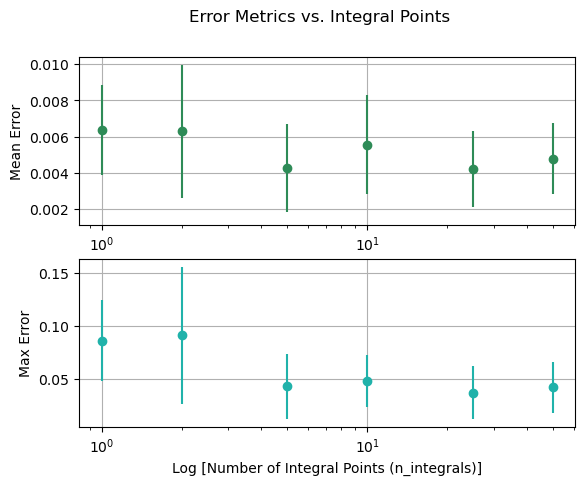

+++++++++MOMENTUM AND ENERGY [MEDIUM]++++++++++++
Loaded Experiment Results:

n_integrals: 0    | Avg MAE: 3.457517e-03 | Avg Time: 2.55e+01s | Avg Max Error: 7.388886e-02
---------------| Std MAE: 1.935814e-03 | Std Time: 6.36e+00s | Std Max Error: 4.192714e-02
n_integrals: 1    | Avg MAE: 5.146204e-03 | Avg Time: 5.28e+01s | Avg Max Error: 8.230838e-02
---------------| Std MAE: 2.584204e-03 | Std Time: 1.13e+01s | Std Max Error: 5.886941e-02
n_integrals: 2    | Avg MAE: 5.065271e-03 | Avg Time: 6.65e+01s | Avg Max Error: 7.568553e-02
---------------| Std MAE: 3.041348e-03 | Std Time: 1.80e+01s | Std Max Error: 6.237716e-02
n_integrals: 5    | Avg MAE: 3.420796e-03 | Avg Time: 9.17e+01s | Avg Max Error: 3.528540e-02
---------------| Std MAE: 1.323030e-03 | Std Time: 2.52e+01s | Std Max Error: 1.284617e-02
n_integrals: 10   | Avg MAE: 3.640448e-03 | Avg Time: 1.15e+02s | Avg Max Error: 3.207408e-02
---------------| Std MAE: 1.205211e-03 | Std Time: 3.92e+01s | Std Max Error: 1.124483e-

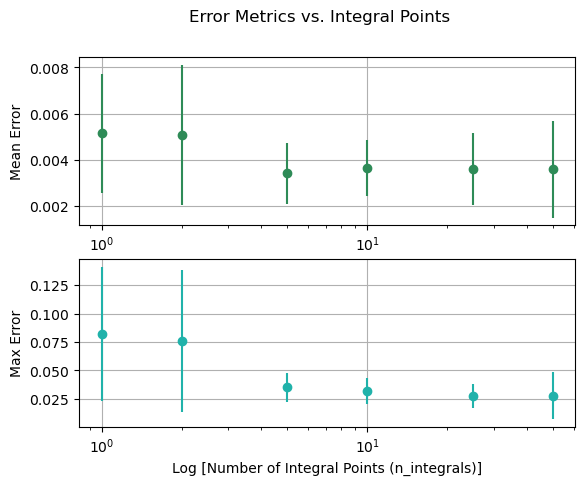

+++++++++MOMENTUM AND ENERGY [LOW]++++++++++++
Loaded Experiment Results:

n_integrals: 0    | Avg MAE: 3.457517e-03 | Avg Time: 2.56e+01s | Avg Max Error: 7.388886e-02
---------------| Std MAE: 1.935814e-03 | Std Time: 6.39e+00s | Std Max Error: 4.192714e-02
n_integrals: 1    | Avg MAE: 3.356824e-03 | Avg Time: 4.03e+01s | Avg Max Error: 5.912646e-02
---------------| Std MAE: 1.939871e-03 | Std Time: 7.66e+00s | Std Max Error: 4.646835e-02
n_integrals: 2    | Avg MAE: 2.756593e-03 | Avg Time: 4.06e+01s | Avg Max Error: 3.698637e-02
---------------| Std MAE: 8.446392e-04 | Std Time: 8.44e+00s | Std Max Error: 1.818676e-02
n_integrals: 5    | Avg MAE: 1.903447e-03 | Avg Time: 5.47e+01s | Avg Max Error: 1.916662e-02
---------------| Std MAE: 6.794637e-04 | Std Time: 2.01e+01s | Std Max Error: 9.371828e-03
n_integrals: 10   | Avg MAE: 1.762641e-03 | Avg Time: 6.20e+01s | Avg Max Error: 1.740307e-02
---------------| Std MAE: 6.084515e-04 | Std Time: 1.95e+01s | Std Max Error: 7.075097e-03


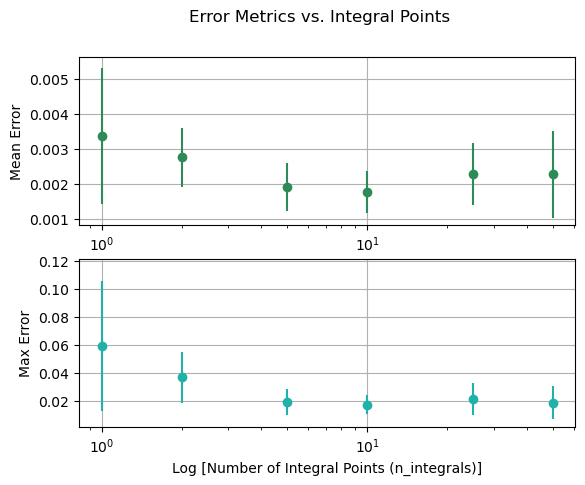

In [15]:
print('+++++++++MOMENTUM AND ENERGY [HIGH]++++++++++++')
single_sol_b_h = reconstruct('data/1_soliton_b_high_backup.pkl')
integrals_v_error(single_sol_b_h)

print('+++++++++MOMENTUM AND ENERGY [MEDIUM]++++++++++++')
single_sol_b_m = reconstruct('data/1_soliton_b_med_backup.pkl')
integrals_v_error(single_sol_b_m)

print('+++++++++MOMENTUM AND ENERGY [LOW]++++++++++++')
single_sol_b_l = reconstruct('data/1_soliton_b_low_backup.pkl')
integrals_v_error(single_sol_b_l)

#### Number of Energy Integrals v. Compute Time [ENERGY]

+++++++++ENERGY [HIGH]++++++++++++
Loaded Experiment Results:

n_integrals: 0    | Avg MAE: 3.457517e-03 | Avg Time: 2.55e+01s | Avg Max Error: 7.388886e-02
---------------| Std MAE: 1.935814e-03 | Std Time: 6.35e+00s | Std Max Error: 4.192714e-02
n_integrals: 1    | Avg MAE: 2.631494e-03 | Avg Time: 3.88e+01s | Avg Max Error: 4.145277e-02
---------------| Std MAE: 1.182828e-03 | Std Time: 1.23e+01s | Std Max Error: 2.138468e-02
n_integrals: 2    | Avg MAE: 2.162346e-03 | Avg Time: 4.23e+01s | Avg Max Error: 2.755892e-02
---------------| Std MAE: 1.190393e-03 | Std Time: 1.27e+01s | Std Max Error: 2.015455e-02
n_integrals: 5    | Avg MAE: 1.688711e-03 | Avg Time: 4.43e+01s | Avg Max Error: 1.912200e-02
---------------| Std MAE: 4.252700e-04 | Std Time: 1.18e+01s | Std Max Error: 8.233022e-03
n_integrals: 10   | Avg MAE: 1.872050e-03 | Avg Time: 5.23e+01s | Avg Max Error: 1.793472e-02
---------------| Std MAE: 6.749604e-04 | Std Time: 1.43e+01s | Std Max Error: 1.058790e-02
n_integrals:

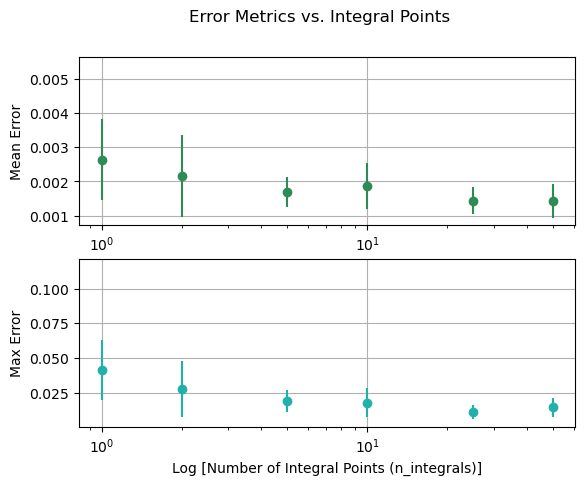

+++++++++ENERGY [MEDIUM]++++++++++++
Loaded Experiment Results:

n_integrals: 0    | Avg MAE: 3.457517e-03 | Avg Time: 2.54e+01s | Avg Max Error: 7.388886e-02
---------------| Std MAE: 1.935814e-03 | Std Time: 6.33e+00s | Std Max Error: 4.192714e-02
n_integrals: 1    | Avg MAE: 2.131875e-03 | Avg Time: 3.78e+01s | Avg Max Error: 2.909336e-02
---------------| Std MAE: 2.075386e-03 | Std Time: 1.11e+01s | Std Max Error: 3.023362e-02
n_integrals: 2    | Avg MAE: 1.759779e-03 | Avg Time: 3.73e+01s | Avg Max Error: 2.008861e-02
---------------| Std MAE: 8.138008e-04 | Std Time: 1.03e+01s | Std Max Error: 1.136731e-02
n_integrals: 5    | Avg MAE: 1.579533e-03 | Avg Time: 3.83e+01s | Avg Max Error: 1.619433e-02
---------------| Std MAE: 7.300242e-04 | Std Time: 9.85e+00s | Std Max Error: 9.053105e-03
n_integrals: 10   | Avg MAE: 1.273059e-03 | Avg Time: 4.66e+01s | Avg Max Error: 1.119722e-02
---------------| Std MAE: 2.922038e-04 | Std Time: 1.03e+01s | Std Max Error: 4.684294e-03
n_integral

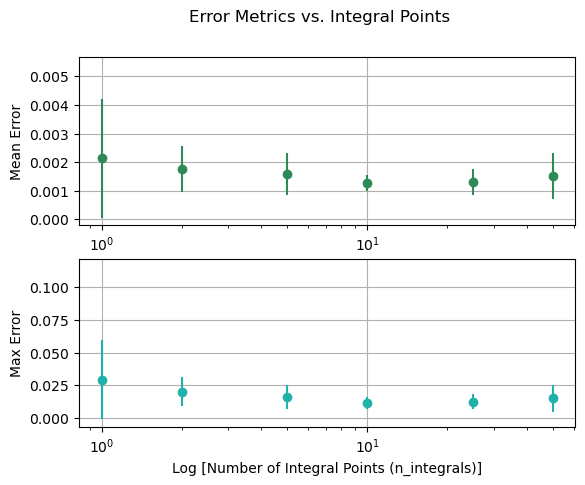

+++++++++ENERGY [LOW]++++++++++++
Loaded Experiment Results:

n_integrals: 0    | Avg MAE: 3.480790e-03 | Avg Time: 2.54e+01s | Avg Max Error: 7.467094e-02
---------------| Std MAE: 1.939537e-03 | Std Time: 6.33e+00s | Std Max Error: 4.206018e-02
n_integrals: 1    | Avg MAE: 1.398487e-03 | Avg Time: 3.26e+01s | Avg Max Error: 2.001456e-02
---------------| Std MAE: 3.876928e-04 | Std Time: 1.29e+01s | Std Max Error: 9.673069e-03
n_integrals: 2    | Avg MAE: 1.358386e-03 | Avg Time: 4.18e+01s | Avg Max Error: 1.372800e-02
---------------| Std MAE: 7.220139e-04 | Std Time: 1.64e+01s | Std Max Error: 1.016393e-02
n_integrals: 5    | Avg MAE: 1.307606e-03 | Avg Time: 4.07e+01s | Avg Max Error: 1.274990e-02
---------------| Std MAE: 5.224732e-04 | Std Time: 1.37e+01s | Std Max Error: 9.793504e-03
n_integrals: 10   | Avg MAE: 1.205920e-03 | Avg Time: 4.22e+01s | Avg Max Error: 1.117432e-02
---------------| Std MAE: 5.493746e-04 | Std Time: 5.97e+00s | Std Max Error: 8.224213e-03
n_integrals: 

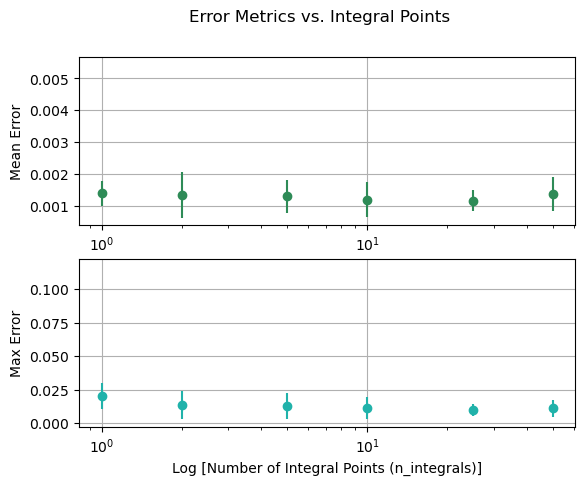

In [17]:
print('+++++++++ENERGY [HIGH]++++++++++++')
single_sol_e_h = reconstruct('data/1_soliton_e_high_backup.pkl')
integrals_v_error(single_sol_e_h)

print('+++++++++ENERGY [MEDIUM]++++++++++++')
single_sol_e_m = reconstruct('data/1_soliton_e_med_backup.pkl')
integrals_v_error(single_sol_e_m)

print('+++++++++ENERGY [LOW]++++++++++++')
single_sol_e_l = reconstruct('data/1_soliton_e_low_backup.pkl')
integrals_v_error(single_sol_e_l)

#### Number of Energy Integrals v. Compute Time [MOMENTUM]

+++++++++MOMENTUM [HIGH]++++++++++++
Loaded Experiment Results:

n_integrals: 0    | Avg MAE: 3.457517e-03 | Avg Time: 2.56e+01s | Avg Max Error: 7.388886e-02
---------------| Std MAE: 1.935814e-03 | Std Time: 6.38e+00s | Std Max Error: 4.192714e-02
n_integrals: 1    | Avg MAE: 1.447698e-02 | Avg Time: 5.25e+01s | Avg Max Error: 2.966741e-01
---------------| Std MAE: 6.645475e-03 | Std Time: 1.44e+01s | Std Max Error: 1.400956e-01
n_integrals: 2    | Avg MAE: 1.447079e-02 | Avg Time: 6.58e+01s | Avg Max Error: 3.081247e-01
---------------| Std MAE: 5.426001e-03 | Std Time: 1.83e+01s | Std Max Error: 1.196505e-01
n_integrals: 5    | Avg MAE: 1.262291e-02 | Avg Time: 7.17e+01s | Avg Max Error: 2.567246e-01
---------------| Std MAE: 4.160345e-03 | Std Time: 1.72e+01s | Std Max Error: 8.998774e-02
n_integrals: 10   | Avg MAE: 1.280604e-02 | Avg Time: 7.29e+01s | Avg Max Error: 2.689847e-01
---------------| Std MAE: 5.280493e-03 | Std Time: 1.64e+01s | Std Max Error: 1.087631e-01
n_integral

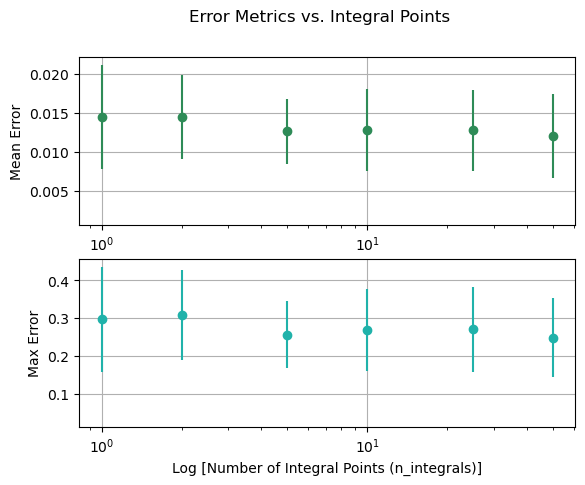

+++++++++MOMENTUM [MEDIUM]++++++++++++
Loaded Experiment Results:

n_integrals: 0    | Avg MAE: 3.480790e-03 | Avg Time: 1.58e+02s | Avg Max Error: 7.467094e-02
---------------| Std MAE: 1.939537e-03 | Std Time: 6.12e+01s | Std Max Error: 4.206018e-02
n_integrals: 1    | Avg MAE: 1.447698e-02 | Avg Time: 3.79e+02s | Avg Max Error: 2.966741e-01
---------------| Std MAE: 6.645475e-03 | Std Time: 1.97e+02s | Std Max Error: 1.400956e-01
n_integrals: 2    | Avg MAE: 1.447079e-02 | Avg Time: 1.62e+02s | Avg Max Error: 3.081247e-01
---------------| Std MAE: 5.426001e-03 | Std Time: 1.52e+02s | Std Max Error: 1.196505e-01
n_integrals: 5    | Avg MAE: 1.262291e-02 | Avg Time: 7.15e+01s | Avg Max Error: 2.567246e-01
---------------| Std MAE: 4.160345e-03 | Std Time: 1.71e+01s | Std Max Error: 8.998774e-02
n_integrals: 10   | Avg MAE: 1.280604e-02 | Avg Time: 7.27e+01s | Avg Max Error: 2.689847e-01
---------------| Std MAE: 5.280493e-03 | Std Time: 1.63e+01s | Std Max Error: 1.087631e-01
n_integr

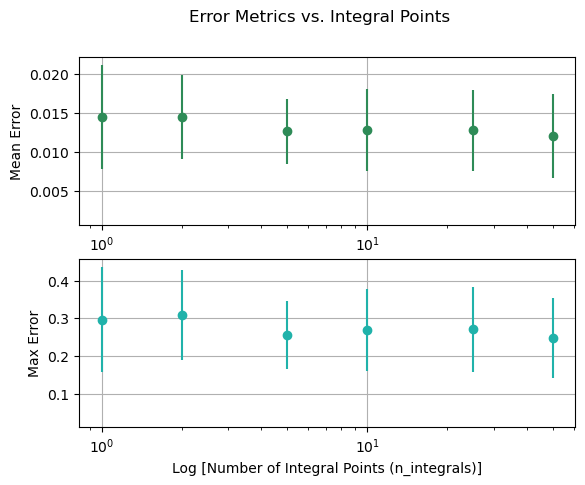

+++++++++MOMENTUM [LOW]++++++++++++
Loaded Experiment Results:

n_integrals: 0    | Avg MAE: 3.457517e-03 | Avg Time: 2.55e+01s | Avg Max Error: 7.388886e-02
---------------| Std MAE: 1.935814e-03 | Std Time: 6.35e+00s | Std Max Error: 4.192714e-02
n_integrals: 1    | Avg MAE: 8.422678e-03 | Avg Time: 4.45e+01s | Avg Max Error: 1.778566e-01
---------------| Std MAE: 3.321153e-03 | Std Time: 1.12e+01s | Std Max Error: 8.811287e-02
n_integrals: 2    | Avg MAE: 8.285023e-03 | Avg Time: 4.58e+01s | Avg Max Error: 1.767593e-01
---------------| Std MAE: 3.457469e-03 | Std Time: 9.82e+00s | Std Max Error: 7.831680e-02
n_integrals: 5    | Avg MAE: 7.675157e-03 | Avg Time: 5.04e+01s | Avg Max Error: 1.653872e-01
---------------| Std MAE: 3.239423e-03 | Std Time: 9.16e+00s | Std Max Error: 7.151990e-02
n_integrals: 10   | Avg MAE: 7.905475e-03 | Avg Time: 5.24e+01s | Avg Max Error: 1.699274e-01
---------------| Std MAE: 2.770846e-03 | Std Time: 1.04e+01s | Std Max Error: 6.145020e-02
n_integrals

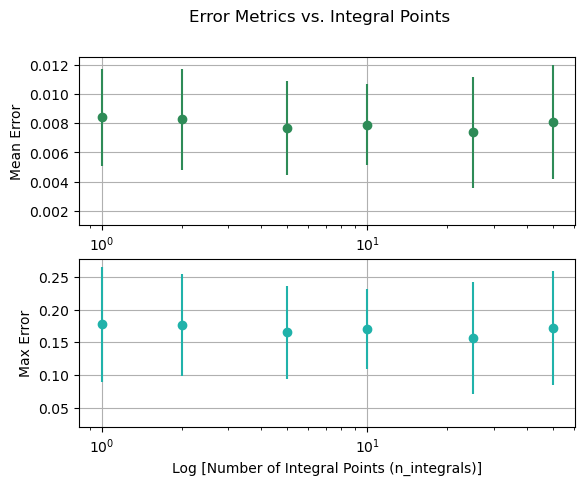

In [16]:
print('+++++++++MOMENTUM [HIGH]++++++++++++')
single_sol_m_h = reconstruct('data/1_soliton_m_high_backup.pkl')
integrals_v_error(single_sol_m_h)

print('+++++++++MOMENTUM [MEDIUM]++++++++++++')
single_sol_m_m = reconstruct('data/1_soliton_m_med_backup.pkl')
integrals_v_error(single_sol_m_m)

print('+++++++++MOMENTUM [LOW]++++++++++++')
single_sol_m_l = reconstruct('data/1_soliton_m_low_backup.pkl')
integrals_v_error(single_sol_m_l)